In [2]:
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_printoptions(sci_mode=False)

In [109]:
file_train = pd.read_csv('mnist_train_small.csv')
file_test = pd.read_csv('mnist_test.csv')
df_train = pd.DataFrame(file_train)
df_test = pd.DataFrame(file_test)
arr_train = df_train.to_numpy()
arr_test = df_test.to_numpy()

pixels_train = arr_train[:, 1:]
pixels_test = arr_test[:, 1:]

pixels_train = pixels_train/255
pixels_test = pixels_test/255

labels_train = torch.tensor(arr_train[:, 0])
pixels_train = torch.tensor(pixels_train).float()

labels_val = torch.tensor(arr_test[:5000, 0])
pixels_val = torch.tensor(pixels_test[:5000]).float()

labels_test = torch.tensor(arr_test[5000:, 0])
pixels_test = torch.tensor(pixels_test[5000:]).float()

print(labels_val.shape)

for i in range(10):
    print(f"Number of training    examples for {i}: ", labels_train[labels_train == i].shape[0])
print("-----------------------------")
for i in range(10):
    print(f"Number of testing     examples for {i}: ", labels_val[labels_val == i].shape[0])
print("-----------------------------")
for i in range(10):
    print(f"Number of validating  examples for {i}: ", labels_test[labels_test == i].shape[0])


nums = 10
pixels = 784

torch.Size([5000])
Number of training    examples for 0:  1962
Number of training    examples for 1:  2243
Number of training    examples for 2:  1989
Number of training    examples for 3:  2021
Number of training    examples for 4:  1924
Number of training    examples for 5:  1761
Number of training    examples for 6:  2038
Number of training    examples for 7:  2126
Number of training    examples for 8:  1912
Number of training    examples for 9:  2023
-----------------------------
Number of testing     examples for 0:  460
Number of testing     examples for 1:  571
Number of testing     examples for 2:  530
Number of testing     examples for 3:  501
Number of testing     examples for 4:  500
Number of testing     examples for 5:  456
Number of testing     examples for 6:  462
Number of testing     examples for 7:  511
Number of testing     examples for 8:  489
Number of testing     examples for 9:  520
-----------------------------
Number of validating  examples for 0:  520
Number o

In [67]:
def calc_accuracy(model, pixels, labels):
    confusion_matrix = torch.zeros((10, 10))

    layers = model.layers
    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False

    with torch.no_grad():
        x = model(pixels)
        preds = torch.argmax(x, dim=1)
        accuracy = (preds == labels).float().mean()
        for i in range(len(labels)):
            confusion_matrix[labels[i], preds[i]] += 1

    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = True

    return accuracy, confusion_matrix

def see(pixels):
    pixels = pixels.view(28, 28)
    plt.matshow(pixels, cmap='gray')

def print_description(epochs, batch_size, learn ,lr_arch, momentum, beta1, beta2, gamma, eps, alpha, beta, L1_regularization, L2_regularization):
    print(f"epochs: {epochs}, batch_size: {batch_size}, alpha: {alpha}, beta: {beta}, corpus size: {labels_train.shape[0]}")
    st = ""
    if L1_regularization:
        st += " L1 Regularization valid"
    if L2_regularization:
        st += " L2 Regularization valid"
    lr_arch_dict = {
        "momentum based" : f" Momentum based , momentum = {momentum} ",
        "adagrad"        : f" AdaGrad , eps = {eps} ",
        "rmsprop"        : f" RMSprop , gamma = {gamma}, eps = {eps} ",
        "adam"           : f" Adam , Beta1 = {beta1} , beta2 = {beta2} ",
        None             : f" Batch GD , learning rate = {learn} "
    }
    st += lr_arch_dict[lr_arch]
    st += f", learn rate = {learn}"
    print(st)


In [68]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.fan_in = fan_in
        self.fan_out = fan_out
        self.bias = bias

        self.weights = torch.randn(fan_in, fan_out)/fan_in**0.5  # kaiming
        self.biases = torch.zeros(fan_out) if bias else None

    def __call__(self, inp):
        prod = inp@self.weights
        if self.biases is not None:
            prod += self.biases
        self.out = prod
        return self.out

    def parameters(self):
        biases = [self.biases] if self.biases is not None else []
        return [self.weights] + biases

    def reset_params(self):
        self.weights = torch.randn(self.fan_in, self.fan_out)/self.fan_in**0.5
        self.biases = torch.zeros(self.fan_out) if self.bias else None

class BatchNorm1d:
    def __init__(self, dim, eps=1e-05, momentum=0.1, training = True):
        self.eps = eps
        self.momentum = momentum
        self.dim = dim

        self.training = training

        self.gamma = torch.ones(1, dim)
        self.beta = torch.zeros(1, dim)

        self.running_mean = torch.zeros(1, dim)
        self.running_var = torch.ones(1, dim)

    def __call__(self, inp):
        if self.training:
            bn_mean = inp.mean(dim=0, keepdim=True)
            bn_var = inp.var(dim=0, keepdim=True, unbiased=False)
        else:
            bn_mean = self.running_mean
            bn_var = self.running_var

        inp_norm = (inp - bn_mean) / torch.sqrt(bn_var+self.eps)
        inp_bn = self.gamma * inp_norm + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * bn_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * bn_var

        self.out = inp_bn
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

    def reset_params(self):
        self.gamma = torch.ones(1, self.dim)
        self.beta = torch.zeros(1, self.dim)

        self.running_mean = torch.zeros(1, self.dim)
        self.running_var = torch.ones(1, self.dim)

class Dropout:
    def __init__(self, p = 0.5):
        self.distr = torch.tensor([1 - p, p])
        self.p = p

    def __call__(self, inp):
        num_elements = inp.view(-1).shape[0]
        mask = torch.multinomial(self.distr, num_elements, replacement=True).view(inp.shape)
        self.out = mask*inp
        return self.out

    def parameters(self):
        return []

class Tanh:
    def __call__(self, inp):
        self.out = torch.tanh(inp)
        return self.out

    def parameters(self):
        return []

class ReLU:
    def __call__(self, inp):
        self.out = torch.relu_(inp)
        return self.out

    def parameters(self):
        return []

class PReLU:
    def __init__(self):
        self.weight = torch.randn(1)
    def __call__(self, inp):
        self.out = torch.prelu(inp, self.weight)
        return self.out

    def parameters(self):
        return [self.weight]

    def reset_params(self):
        self.weight = torch.randn(1)

class SoftMax:
    def __call__(self, arr):
        logits = torch.exp(arr)
        self.out = logits/logits.sum(dim = 1)
        return self.out

    def parameters(self):
        return []

class Embedding:
    def __init__(self, vocab_size, emb_size):
        self.vocab_size = vocab_size
        self.emb_size = emb_size

        self.weight = torch.randn((vocab_size, emb_size))

    def __call__(self, inp):
        self.out = self.weight[inp]
        return self.out

    def parameters(self):
        return [self.weight]

    def reset_params(self):
        self.weight = torch.randn((self.vocab_size, self.emb_size))

class Flatten:
    def __call__(self, arr):
        shape = 1 if len(arr.shape) == 2 else arr.shape[0]
        self.out = arr.view(shape, -1)
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers
        self.params = [p for layer in self.layers for p in layer.parameters()]

    def __call__(self, inp):
        self.out = inp
        for layer in self.layers:
            self.out = layer(self.out)
        return self.out

    def n_parameters(self):
        return sum(p.nelement() for p in self.params)

    def reset_params(self, seed=None):
        if seed is not None:
            torch.manual_seed(seed)
        for layer in self.layers:
            if hasattr(layer, 'reset_params'):
                layer.reset_params()
        self.params = [p for layer in self.layers for p in layer.parameters()]

In [69]:
def train_model(iterations, batch_size, model, pixels_train, labels_train, learn = 0.1, lr_arch = None, momentum = 0.1, beta1 = 0.9, beta2 = 0.9, t = 2 ,gamma = 0.9, eps = 1e-5, alpha = 0.01, beta = 0.01, L1_regularization = False, L2_regularization = False, seed=None):
    # ------------------------------   INIIALIZATION AND PRINTING STUFF   -----------------------------------------
    model.reset_params(seed)
    print_description(iterations, batch_size, lr_arch = lr_arch,\
                      momentum = momentum, beta1 = beta1, beta2 = beta2, gamma = gamma,\
                      eps = eps, alpha = alpha, beta = beta, learn = learn, \
                      L1_regularization=L1_regularization , L2_regularization=L2_regularization)

    for p in model.params:
        p.requires_grad = True

    if lr_arch == "momentum based":
        velocities = [torch.zeros_like(p) for p in model.params]
    if lr_arch == "adagrad":
        accum_grad = [torch.zeros_like(p) for p in model.params]
    if lr_arch == "rmsprop":
        accum_grad_exp = [torch.zeros_like(p) for p in model.params]
    if lr_arch ==  "adam":
        accum_mt = [torch.zeros_like(p) for p in model.params]
        accum_vt = [torch.zeros_like(p) for p in model.params]

    # -------------------------------------training and backprop--------------------------------------------------------------

    for _ in range(iterations):
        # Forward Pass
        ix = torch.randint(0, pixels_train.shape[0], (batch_size,))
        Xb, Yb = pixels_train[ix], labels_train[ix]

        x = model(Xb)

        ridge = 0
        lasso = 0
        if L2_regularization:
            for l in model.layers:
                if isinstance(l, Linear):
                    ridge = ridge + (l.weights**2).mean()

        if L1_regularization:
            for l in model.layers:
                if isinstance(l, Linear):
                    lasso = lasso + (abs(l.weights)).mean()

        loss = F.cross_entropy(x, Yb) + alpha*ridge + beta*lasso

        # Backward pass
        for p in model.params:
            p.grad = None

        loss.backward()

        # update steps
        lr = learn
        for i in range(len(model.params)):
            if lr_arch == "adam":
                accum_mt[i] = beta1*accum_mt[i] + (1-beta1)*model.params[i].grad
                accum_vt[i] = beta2*accum_vt[i] + (1-beta2)*model.params[i].grad**2

                t = _ + 1

                mt_hat = accum_mt[i]/(1-beta1**t)
                vt_hat = accum_vt[i]/(1-beta2**t)

                update = (mt_hat/(vt_hat**0.5 + eps)) * lr

            elif lr_arch == "rmsprop":
                accum_grad_exp[i] = gamma*accum_grad_exp[i] + (1-gamma)*model.params[i].grad**2
                update = (model.params[i].grad/(accum_grad_exp[i] + eps)**0.5) * lr

            elif lr_arch == "momentum based":
                velocities[i] = lr*model.params[i].grad + momentum*velocities[i]
                update = velocities[i]

            elif lr_arch == "adagrad":
                accum_grad[i] = accum_grad[i] + model.params[i].grad**2
                update = (model.params[i].grad/(accum_grad[i] + eps)**0.5) * lr

            else:
                update = lr*model.params[i].grad

            model.params[i].data += -update

        if _ % 100 == 0:
            # print(f"{_}/{iterations} : {loss.item()}")
            pass

    return model

In [70]:
seed = 232325325
gain = {"Tanh" : (5/3)**0.5, "ReLU" : 2**0.5}

n_hidden = 260

model = Sequential([
        Linear(pixels, n_hidden, bias=False), BatchNorm1d(n_hidden), PReLU(),
        Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), PReLU(),
        Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), PReLU(),
        Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), PReLU(),
        Linear(n_hidden, nums, bias=False), BatchNorm1d(nums)
    ])

n = len(model.layers)

with torch.no_grad():
    if isinstance(model.layers[-1], Linear):
        model.layers[-1].weights *= 0.01
    elif isinstance(model.layers[-1], BatchNorm1d):
        model.layers[-1].gamma *= 0.01

    for i in range(n - 1):
        layer = model.layers[i]
        if isinstance(layer, Linear):
            if i < n - 1 and model.layers[i+1].__class__.__name__ in gain:
                layer.weights *= gain[model.layers[i+1].__class__.__name__]
        if isinstance(layer, BatchNorm1d):
            layer.training = True

        model.layers[i] = layer

In [94]:
iterations = 14000
batch_size = 32

lr_archs = [("rmsprop", 0.001), ("adam", 0.001), ("adagrad", 0.01), ("momentum based", 0.1), (None, 0.1)]

matrices = []
titles = []
models = {}

In [99]:
print(f"Num Params : {model.n_parameters()}")
import copy

for i in range(5):
    lr_arch, learn = lr_archs[i]

    model_trained = train_model(iterations, batch_size, model, pixels_train, labels_train, lr_arch = lr_arch, learn = learn, L2_regularization=True,seed = seed)

    train_acc, conf_mx_train = calc_accuracy(model_trained, pixels_train, labels_train)
    train_err = 1 - train_acc

    val_acc, conf_mx_val = calc_accuracy(model_trained, pixels_val, labels_val)
    val_err = 1 - val_acc

    print(f"Accuracy of model {i} on train : {train_acc*100}%")
    print(f"Accuracy of model {i} on  eval : {val_acc*100}%")

    matrices.append(conf_mx_val)
    titles.append(f"Model {i}")
    models[lr_arch] = copy.deepcopy(model_trained)

Num Params : 411344
epochs: 14000, batch_size: 32, alpha: 0.01, beta: 0.01, corpus size: 19999
 L2 Regularization valid RMSprop , gamma = 0.9, eps = 1e-05 , learn rate = 0.001
Accuracy of model 0 on train : 99.93999481201172%
Accuracy of model 0 on  eval : 96.9000015258789%
epochs: 14000, batch_size: 32, alpha: 0.01, beta: 0.01, corpus size: 19999
 L2 Regularization valid Adam , Beta1 = 0.9 , beta2 = 0.9 , learn rate = 0.001
Accuracy of model 1 on train : 99.84999084472656%
Accuracy of model 1 on  eval : 96.31999969482422%
epochs: 14000, batch_size: 32, alpha: 0.01, beta: 0.01, corpus size: 19999
 L2 Regularization valid AdaGrad , eps = 1e-05 , learn rate = 0.01
Accuracy of model 2 on train : 99.98500061035156%
Accuracy of model 2 on  eval : 96.69999694824219%
epochs: 14000, batch_size: 32, alpha: 0.01, beta: 0.01, corpus size: 19999
 L2 Regularization valid Momentum based , momentum = 0.1 , learn rate = 0.1
Accuracy of model 3 on train : 99.98500061035156%
Accuracy of model 3 on  eval

In [104]:
# validation
for lr, model_ in models.items():
    x = model_(pixels_val)

    ridge = 0
    for l in model.layers:
        if isinstance(l, Linear):
            ridge = ridge + (l.weights**2).mean()

    lossv = F.cross_entropy(x, labels_val) + 0.01*ridge
    print(f"val loss on model {lr} : {lossv}")

val loss on model rmsprop : 0.14781267940998077
val loss on model adam : 0.1675647795200348
val loss on model adagrad : 0.13741619884967804
val loss on model momentum based : 0.14120647311210632
val loss on model None : 0.13184835016727448


In [107]:
model_ = models["rmsprop"]

x = model_(pixels_val)

ridge = 0
for l in model_.layers:
    if isinstance(l, Linear):
        ridge = ridge + (l.weights**2).mean()

lossv = F.cross_entropy(x, labels_val) + 0.01*ridge
print(f"loss on model RMSprop : {lossv}")
accuracy, conf_mx_test = calc_accuracy(model_, pixels_test, labels_test)
print("Accuracy on RMSprop model: ", accuracy.item()*100, "%")
print("Confusion matrix : ")
print(conf_mx_test)

loss on model RMSprop : 0.14785704016685486
Accuracy on RMSprop model:  98.65972995758057 %
Confusion matrix : 
tensor([[515.,   1.,   1.,   0.,   0.,   1.,   0.,   0.,   1.,   1.],
        [  0., 563.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.],
        [  0.,   0., 496.,   0.,   1.,   0.,   0.,   4.,   1.,   0.],
        [  1.,   0.,   6., 492.,   0.,   1.,   0.,   1.,   7.,   1.],
        [  0.,   0.,   1.,   0., 477.,   1.,   0.,   1.,   0.,   2.],
        [  1.,   0.,   1.,   3.,   0., 428.,   1.,   0.,   1.,   1.],
        [  1.,   0.,   0.,   0.,   4.,   2., 489.,   0.,   0.,   0.],
        [  0.,   0.,   5.,   0.,   0.,   0.,   0., 511.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   2.,   1.,   1., 478.,   2.],
        [  1.,   0.,   0.,   0.,   1.,   1.,   0.,   2.,   1., 483.]])


In [108]:
model_ = models[None]

x = model_(pixels_val)

ridge = 0
for l in model_.layers:
    if isinstance(l, Linear):
        ridge = ridge + (l.weights**2).mean()

lossv = F.cross_entropy(x, labels_val) + 0.01*ridge
print(f"loss on model plane SGD : {lossv}")
accuracy, conf_mx_test = calc_accuracy(model_, pixels_test, labels_test)
print("Accuracy on SGD model: ", accuracy.item()*100, "%")
print("Confusion matrix : ")
print(conf_mx_test)

loss on model plane SGD : 0.13184835016727448
Accuracy on SGD model:  98.77975583076477 %
Confusion matrix : 
tensor([[517.,   1.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.],
        [  0., 559.,   0.,   0.,   0.,   1.,   2.,   0.,   2.,   0.],
        [  0.,   0., 499.,   1.,   0.,   0.,   1.,   0.,   1.,   0.],
        [  0.,   1.,   1., 495.,   0.,   6.,   0.,   0.,   6.,   0.],
        [  2.,   0.,   0.,   0., 477.,   0.,   0.,   1.,   0.,   2.],
        [  1.,   0.,   0.,   1.,   0., 431.,   2.,   0.,   1.,   0.],
        [  2.,   0.,   0.,   1.,   0.,   1., 492.,   0.,   0.,   0.],
        [  1.,   0.,   3.,   1.,   1.,   0.,   0., 506.,   1.,   3.],
        [  0.,   0.,   0.,   0.,   1.,   4.,   2.,   0., 477.,   1.],
        [  1.,   0.,   0.,   0.,   2.,   0.,   0.,   1.,   0., 485.]])


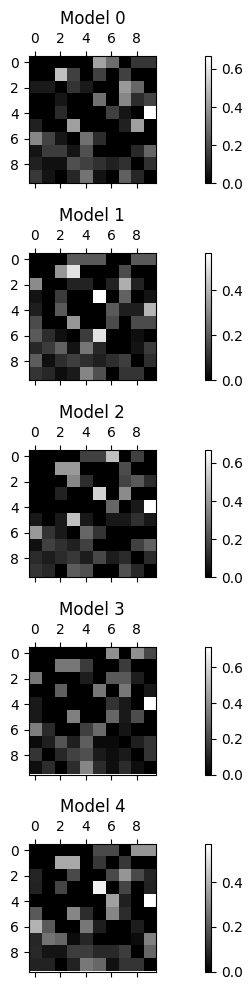

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))

axes = axes.ravel()

matrices[0].fill_diagonal_(0)
matrices[0] = matrices[i]/matrices[i].sum(dim = 1, keepdim=True)

matrices[4].fill_diagonal_(0)
matrices[4] = matrices[i]/matrices[i].sum(dim = 1, keepdim=True)

matrices, titles = [matrices[0], matrices[4]], [titles[0], titles[4]]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat, cmap=plt.cm.gray)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()